# Projet : Système de Recommandation d'Images

**Auteurs** : BONNET & DURANO  
**Date** : Février 2026

---

## Objectif du projet

Construire un système de recommandation d'images qui suggère des images aux utilisateurs en fonction de leurs préférences.

### Architecture du système

1. **Collecte de données** : Téléchargement de 100+ images depuis Unsplash API
2. **Étiquetage et annotation** : Extraction de couleurs, orientation, tags
3. **Analyse de données** : Création de profils utilisateur basés sur leurs favoris
4. **Visualisation** : 6+ graphiques pour analyser les données
5. **Système de recommandation** : Filtrage basé sur le contenu (classification)
6. **Tests** : Validation de l'intégrité et de la qualité du système

---


## 📦 Configuration et Imports

Installation des bibliothèques nécessaires et imports.

In [1]:
# Installation des bibliothèques nécessaires (à exécuter une seule fois)
# !pip install python-dotenv requests pillow scikit-learn matplotlib pandas webcolors

In [2]:
# Imports standards
import os
import json
import requests
from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Data science
import numpy as np
import pandas as pd

# Image processing
from PIL import Image
from PIL.ExifTags import TAGS

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuration
from dotenv import load_dotenv

# Charger les variables d'environnement depuis .env
load_dotenv()

print("✅ Imports terminés avec succès")

✅ Imports terminés avec succès


In [3]:
# Configuration des chemins
PROJECT_DIR = Path.cwd()
IMAGES_DIR = PROJECT_DIR / "images"
DATA_DIR = PROJECT_DIR / "data"

# Créer les dossiers s'ils n'existent pas
IMAGES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# Fichiers de données
METADATA_FILE = DATA_DIR / "images_metadata.json"
LABELS_FILE = DATA_DIR / "images_labels.json"
USERS_FILE = DATA_DIR / "users.json"

# Configuration Unsplash API
UNSPLASH_ACCESS_KEY = os.getenv("UNSPLASH_ACCESS_KEY")

if not UNSPLASH_ACCESS_KEY:
    raise ValueError("❌ Clé API Unsplash manquante ! Vérifiez le fichier .env")

print(f"📁 Dossier projet : {PROJECT_DIR}")
print(f"📁 Dossier images : {IMAGES_DIR}")
print(f"📁 Dossier données : {DATA_DIR}")
print(f"🔑 Clé API Unsplash : {'*' * len(UNSPLASH_ACCESS_KEY)}")

📁 Dossier projet : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1
📁 Dossier images : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\images
📁 Dossier données : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data
🔑 Clé API Unsplash : *******************************************


---

## 🎯 Tâche 1 : Collecte de Données

**Objectif** : Collecter au moins 100 images sous licence ouverte avec leurs métadonnées.

**Métadonnées à extraire** :
- Nom du fichier image
- Dimensions (largeur, hauteur)
- Format du fichier
- Taille du fichier (Ko)
- URL source
- Informations de licence
- Données EXIF (si disponibles)

In [4]:
def fetch_unsplash_images(query: str = "nature", per_page: int = 30, pages: int = 4) -> List[Dict]:
    """
    Récupère des images depuis Unsplash API.
    
    Args:
        query: Terme de recherche
        per_page: Nombre d'images par page (max 30)
        pages: Nombre de pages à récupérer
    
    Returns:
        Liste de dictionnaires contenant les infos des images
    """
    base_url = "https://api.unsplash.com/search/photos"
    headers = {"Authorization": f"Client-ID {UNSPLASH_ACCESS_KEY}"}
    
    images_data = []
    
    for page in range(1, pages + 1):
        params = {
            "query": query,
            "per_page": per_page,
            "page": page
        }
        
        try:
            response = requests.get(base_url, headers=headers, params=params, timeout=10)
            response.raise_for_status()
            
            data = response.json()
            images_data.extend(data.get("results", []))
            
            print(f"✅ Page {page}/{pages} récupérée : {len(data.get('results', []))} images")
            
        except Exception as e:
            print(f"❌ Erreur page {page} : {e}")
            continue
    
    return images_data

In [5]:
def download_image(url: str, filename: str) -> bool:
    """
    Télécharge une image depuis une URL.
    
    Args:
        url: URL de l'image
        filename: Nom du fichier de destination
    
    Returns:
        True si succès, False sinon
    """
    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        
        filepath = IMAGES_DIR / filename
        filepath.write_bytes(response.content)
        
        return True
    except Exception as e:
        print(f"❌ Erreur téléchargement {filename} : {e}")
        return False

In [ ]:
def extract_exif_data(image_path: Path) -> Dict:
    """
    Extrait les données EXIF d'une image.

    Note : L'API Unsplash renvoie des JPEG recompressés sans bloc EXIF embarqué.
    Dans ce cas, _getexif() retourne None et la fonction renvoie un dict vide {}.
    Ce comportement est attendu et conforme à la consigne "si disponibles".

    Args:
        image_path: Chemin vers l'image

    Returns:
        Dictionnaire contenant les données EXIF (vide si absent)
    """
    exif_data = {}

    try:
        img = Image.open(image_path)
        exif = img._getexif()

        if exif:
            for tag_id, value in exif.items():
                tag = TAGS.get(tag_id, tag_id)
                exif_data[tag] = str(value)
    except:
        pass

    return exif_data


In [7]:
def collect_images_metadata(queries: List[str] = ["nature", "architecture", "food", "animals"], 
                           per_query: int = 30) -> Dict:
    """
    Collecte des images et leurs métadonnées depuis Unsplash.
    
    Args:
        queries: Liste de termes de recherche
        per_query: Nombre d'images par requête
    
    Returns:
        Dictionnaire contenant toutes les métadonnées
    """
    all_metadata = {}
    image_counter = 1
    
    for query in queries:
        print(f"\n🔍 Recherche : '{query}'")
        images_data = fetch_unsplash_images(query, per_page=per_query, pages=1)
        
        for img_data in images_data:
            filename = f"image_{image_counter:03d}.jpg"
            image_url = img_data["urls"]["regular"]
            
            # Télécharger l'image
            if download_image(image_url, filename):
                image_path = IMAGES_DIR / filename
                
                # Ouvrir l'image pour extraire les infos
                try:
                    with Image.open(image_path) as img:
                        width, height = img.size
                        format_img = img.format
                except:
                    print(f"⚠️ Impossible d'ouvrir {filename}")
                    continue
                
                # Taille du fichier en Ko
                file_size_kb = image_path.stat().st_size / 1024
                
                # Extraire données EXIF
                exif_data = extract_exif_data(image_path)
                
                # Stocker les métadonnées
                all_metadata[filename] = {
                    "filename": filename,
                    "width": width,
                    "height": height,
                    "format": format_img,
                    "file_size_kb": round(file_size_kb, 2),
                    "source_url": img_data["links"]["html"],
                    "download_url": image_url,
                    "license": "Unsplash License",
                    "author": img_data["user"]["name"],
                    "author_url": img_data["user"]["links"]["html"],
                    "description": img_data.get("description", ""),
                    "alt_description": img_data.get("alt_description", ""),
                    "query": query,
                    "exif": exif_data
                }
                
                print(f"✅ {filename} : {width}x{height}, {file_size_kb:.1f} Ko")
                image_counter += 1
    
    return all_metadata

In [8]:
# Collecte des images (peut prendre quelques minutes)
print("🚀 Début de la collecte d'images...\n")

# Diversifier les requêtes pour avoir une collection variée
search_queries = ["nature", "architecture", "food", "animals", "technology", "art"]

metadata = collect_images_metadata(queries=search_queries, per_query=20)

print(f"\n✅ Collecte terminée : {len(metadata)} images téléchargées")

🚀 Début de la collecte d'images...


🔍 Recherche : 'nature'
✅ Page 1/1 récupérée : 20 images
✅ image_001.jpg : 1080x715, 112.0 Ko
✅ image_002.jpg : 1080x1620, 661.1 Ko
✅ image_003.jpg : 1080x643, 136.7 Ko
✅ image_004.jpg : 1080x1783, 426.2 Ko
✅ image_005.jpg : 1080x1620, 631.6 Ko
✅ image_006.jpg : 1080x1620, 222.2 Ko
✅ image_007.jpg : 1080x717, 108.7 Ko
✅ image_008.jpg : 1080x1620, 307.8 Ko
✅ image_009.jpg : 1080x720, 100.6 Ko
✅ image_010.jpg : 1080x720, 237.3 Ko
✅ image_011.jpg : 1080x1922, 350.1 Ko
✅ image_012.jpg : 1080x1618, 852.9 Ko
✅ image_013.jpg : 1080x720, 180.3 Ko
✅ image_014.jpg : 1080x643, 169.0 Ko
✅ image_015.jpg : 1080x1620, 212.8 Ko
✅ image_016.jpg : 1080x721, 137.0 Ko
✅ image_017.jpg : 1080x675, 168.3 Ko
✅ image_018.jpg : 1080x720, 96.3 Ko
✅ image_019.jpg : 1080x1620, 465.8 Ko
✅ image_020.jpg : 1080x810, 54.0 Ko

🔍 Recherche : 'architecture'
✅ Page 1/1 récupérée : 20 images
✅ image_021.jpg : 1080x720, 99.0 Ko
✅ image_022.jpg : 1080x720, 100.7 Ko
✅ image_023.jpg : 1080x7

In [9]:
# Sauvegarder les métadonnées
with open(METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"💾 Métadonnées sauvegardées : {METADATA_FILE}")
print(f"📊 Nombre total d'images : {len(metadata)}")

💾 Métadonnées sauvegardées : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\data\images_metadata.json
📊 Nombre total d'images : 120


In [10]:
# Afficher quelques statistiques rapides
df_meta = pd.DataFrame(metadata).T

print("\n📈 Statistiques de la collection :")
print(f"  - Taille moyenne : {df_meta['file_size_kb'].mean():.2f} Ko")
print(f"  - Largeur moyenne : {df_meta['width'].mean():.0f} px")
print(f"  - Hauteur moyenne : {df_meta['height'].mean():.0f} px")
print(f"\n  - Formats : {df_meta['format'].value_counts().to_dict()}")
print(f"\n  - Requêtes : {df_meta['query'].value_counts().to_dict()}")


📈 Statistiques de la collection :
  - Taille moyenne : 211.97 Ko
  - Largeur moyenne : 1080 px
  - Hauteur moyenne : 1091 px

  - Formats : {'JPEG': 120}

  - Requêtes : {'nature': 20, 'architecture': 20, 'food': 20, 'animals': 20, 'technology': 20, 'art': 20}


---

## 🏷️ Tâche 2 : Étiquetage et Annotation

**Objectif** : Ajouter des étiquettes descriptives et des caractéristiques calculées.

**Caractéristiques à extraire** :
- Couleurs prédominantes (3-5 couleurs via KMeans)
- Orientation (paysage, portrait, carré)
- Catégorie de taille (vignette, moyenne, grande)
- Tags descriptifs (automatisés depuis Unsplash)

In [ ]:
def rgb_to_name(rgb: Tuple[int, int, int]) -> str:
    """
    Convertit une couleur RGB en nom approximatif.

    Args:
        rgb: Tuple (R, G, B)

    Returns:
        Nom de couleur approximatif
    """
    r, g, b = rgb

    # Couleurs de base simplifiées
    if r > 200 and g < 100 and b < 100:
        return "rouge"
    elif r < 100 and g > 200 and b < 100:
        return "vert"
    elif r < 100 and g < 100 and b > 200:
        return "bleu"
    elif r > 200 and g > 200 and b < 100:
        return "jaune"
    elif r > 200 and g < 150 and b > 200:
        return "magenta"
    elif r < 150 and g > 200 and b > 200:
        return "cyan"
    elif r > 220 and g > 220 and b > 220:
        return "blanc"
    elif r < 50 and g < 50 and b < 50:
        return "noir"
    elif abs(r - g) < 20 and abs(g - b) < 20:
        return "gris"
    elif r > 200 and g > 150 and b < 100:
        return "orange"
    elif r > 150 and g > 100 and b < 80:
        return "marron"
    elif r > 200 and g > 150 and b > 200:
        return "rose"
    else:
        # Dominante : distinguer rouge vif des tons bruns/kaki/ocre
        # (évite le sur-classement des couleurs chaudes neutres en "rouge")
        if r > g and r > b:
            if r > 140 and g > 75 and b < 100:
                return "marron"  # tons bruns, kaki, ocre, sable
            return "rouge"
        elif g > r and g > b:
            return "vert"
        else:
            return "bleu"


In [12]:
def extract_dominant_colors(image_path: Path, n_colors: int = 5) -> List[List[int]]:
    """
    Extrait les couleurs dominantes d'une image avec KMeans.
    
    Args:
        image_path: Chemin vers l'image
        n_colors: Nombre de couleurs à extraire
    
    Returns:
        Liste de couleurs RGB
    """
    try:
        # Charger et redimensionner l'image (pour accélérer)
        img = Image.open(image_path)
        img.thumbnail((200, 200))
        
        # Convertir en tableau numpy
        img_array = np.array(img)
        
        # Si grayscale, convertir en RGB
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        elif img_array.shape[2] == 4:  # RGBA
            img_array = img_array[:, :, :3]
        
        # Reshape pour KMeans
        pixels = img_array.reshape(-1, 3)
        
        # Appliquer KMeans
        kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
        kmeans.fit(pixels)
        
        # Récupérer les centres (couleurs dominantes)
        colors = kmeans.cluster_centers_.astype(int).tolist()
        
        return colors
    
    except Exception as e:
        print(f"❌ Erreur extraction couleurs {image_path.name} : {e}")
        return [[128, 128, 128]]  # Gris par défaut

In [13]:
def get_orientation(width: int, height: int) -> str:
    """
    Détermine l'orientation d'une image.
    
    Args:
        width: Largeur de l'image
        height: Hauteur de l'image
    
    Returns:
        'paysage', 'portrait' ou 'carré'
    """
    ratio = width / height
    
    if 0.95 <= ratio <= 1.05:
        return "carré"
    elif ratio > 1.05:
        return "paysage"
    else:
        return "portrait"

In [14]:
def get_size_category(width: int, height: int) -> str:
    """
    Détermine la catégorie de taille d'une image.
    
    Args:
        width: Largeur de l'image
        height: Hauteur de l'image
    
    Returns:
        'vignette', 'moyenne' ou 'grande'
    """
    max_dimension = max(width, height)
    
    if max_dimension < 500:
        return "vignette"
    elif max_dimension <= 1500:
        return "moyenne"
    else:
        return "grande"

In [15]:
def create_labels():
    """
    Crée les labels pour toutes les images.
    
    Returns:
        Dictionnaire contenant tous les labels
    """
    # Charger les métadonnées
    with open(METADATA_FILE, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    labels = {}
    
    for filename, meta in metadata.items():
        print(f"🏷️ Étiquetage : {filename}")
        
        image_path = IMAGES_DIR / filename
        
        # Extraire couleurs dominantes
        dominant_colors = extract_dominant_colors(image_path, n_colors=5)
        
        # Convertir RGB en noms
        color_names = [rgb_to_name(tuple(color)) for color in dominant_colors]
        
        # Orientation
        orientation = get_orientation(meta["width"], meta["height"])
        
        # Catégorie de taille
        size_category = get_size_category(meta["width"], meta["height"])
        
        # Tags (depuis la description/query)
        tags = [meta["query"]]
        if meta.get("alt_description"):
            # Extraire quelques mots-clés de la description
            words = meta["alt_description"].lower().split()
            tags.extend([w for w in words if len(w) > 3][:5])
        
        # Stocker les labels
        labels[filename] = {
            "predominant_colors": dominant_colors,
            "color_names": color_names,
            "orientation": orientation,
            "size_category": size_category,
            "tags": list(set(tags))  # Enlever les doublons
        }
    
    return labels

In [16]:
# Créer les labels (peut prendre quelques minutes)
print("🚀 Début de l'étiquetage...\n")

labels = create_labels()

print(f"\n✅ Étiquetage terminé : {len(labels)} images annotées")

🚀 Début de l'étiquetage...

🏷️ Étiquetage : image_001.jpg
🏷️ Étiquetage : image_002.jpg
🏷️ Étiquetage : image_003.jpg
🏷️ Étiquetage : image_004.jpg
🏷️ Étiquetage : image_005.jpg
🏷️ Étiquetage : image_006.jpg
🏷️ Étiquetage : image_007.jpg
🏷️ Étiquetage : image_008.jpg
🏷️ Étiquetage : image_009.jpg
🏷️ Étiquetage : image_010.jpg
🏷️ Étiquetage : image_011.jpg
🏷️ Étiquetage : image_012.jpg
🏷️ Étiquetage : image_013.jpg
🏷️ Étiquetage : image_014.jpg
🏷️ Étiquetage : image_015.jpg
🏷️ Étiquetage : image_016.jpg
🏷️ Étiquetage : image_017.jpg
🏷️ Étiquetage : image_018.jpg
🏷️ Étiquetage : image_019.jpg
🏷️ Étiquetage : image_020.jpg
🏷️ Étiquetage : image_021.jpg
🏷️ Étiquetage : image_022.jpg
🏷️ Étiquetage : image_023.jpg
🏷️ Étiquetage : image_024.jpg
🏷️ Étiquetage : image_025.jpg
🏷️ Étiquetage : image_026.jpg
🏷️ Étiquetage : image_027.jpg
🏷️ Étiquetage : image_028.jpg
🏷️ Étiquetage : image_029.jpg
🏷️ Étiquetage : image_030.jpg
🏷️ Étiquetage : image_031.jpg
🏷️ Étiquetage : image_032.jpg
🏷️ Étiquetag

In [17]:
# Sauvegarder les labels
with open(LABELS_FILE, "w", encoding="utf-8") as f:
    json.dump(labels, f, ensure_ascii=False, indent=2)

print(f"💾 Labels sauvegardés : {LABELS_FILE}")

💾 Labels sauvegardés : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\data\images_labels.json


In [18]:
# Afficher un exemple
example_filename = list(labels.keys())[0]
print(f"\n📋 Exemple de labels pour {example_filename} :")
print(json.dumps(labels[example_filename], indent=2, ensure_ascii=False))


📋 Exemple de labels pour image_001.jpg :
{
  "predominant_colors": [
    [
      245,
      243,
      239
    ],
    [
      180,
      144,
      62
    ],
    [
      221,
      206,
      180
    ],
    [
      203,
      164,
      100
    ],
    [
      142,
      114,
      27
    ]
  ],
  "color_names": [
    "blanc",
    "marron",
    "rouge",
    "rouge",
    "rouge"
  ],
  "orientation": "paysage",
  "size_category": "moyenne",
  "tags": [
    "orange",
    "nature",
    "flowers"
  ]
}


---

## 👥 Tâche 3 : Analyse de Données

**Objectif** : Construire des profils de préférences utilisateur basés sur leurs sélections.

**Profil utilisateur** :
- Couleurs favorites
- Orientation favorite
- Taille favorite
- Tags favoris

In [19]:
def create_simulated_users(n_users: int = 5, min_favorites: int = 10, max_favorites: int = 20) -> Dict:
    """
    Crée des utilisateurs simulés avec des préférences différentes.
    
    Args:
        n_users: Nombre d'utilisateurs à créer
        min_favorites: Nombre minimum de favoris par utilisateur
        max_favorites: Nombre maximum de favoris par utilisateur
    
    Returns:
        Dictionnaire contenant les profils utilisateurs
    """
    # Charger les labels
    with open(LABELS_FILE, "r", encoding="utf-8") as f:
        labels = json.load(f)
    
    all_images = list(labels.keys())
    
    # Profils prédéfinis pour diversité
    user_preferences = [
        {"name": "Amoureux de la nature", "preferred_tags": ["nature", "animals"], "preferred_colors": ["vert", "bleu"]},
        {"name": "Fan d'architecture", "preferred_tags": ["architecture", "technology"], "preferred_colors": ["gris", "blanc", "noir"]},
        {"name": "Foodie", "preferred_tags": ["food"], "preferred_colors": ["rouge", "orange", "jaune"]},
        {"name": "Artiste", "preferred_tags": ["art"], "preferred_colors": ["magenta", "cyan", "rose"]},
        {"name": "Éclectique", "preferred_tags": [], "preferred_colors": []},
    ]
    
    users = {}
    
    for i in range(n_users):
        user_id = f"user_{i+1:03d}"
        prefs = user_preferences[i % len(user_preferences)]
        
        # Sélectionner des favoris selon les préférences
        if prefs["preferred_tags"]:
            # Filtrer par tags préférés
            matching_images = [
                img for img in all_images
                if any(tag in labels[img]["tags"] for tag in prefs["preferred_tags"])
            ]
            
            if matching_images:
                n_favs = min(len(matching_images), np.random.randint(min_favorites, max_favorites + 1))
                favorites = np.random.choice(matching_images, n_favs, replace=False).tolist()
            else:
                n_favs = np.random.randint(min_favorites, max_favorites + 1)
                favorites = np.random.choice(all_images, n_favs, replace=False).tolist()
        else:
            # Sélection aléatoire
            n_favs = np.random.randint(min_favorites, max_favorites + 1)
            favorites = np.random.choice(all_images, n_favs, replace=False).tolist()
        
        users[user_id] = {
            "user_id": user_id,
            "name": prefs["name"],
            "favorite_images": favorites
        }
    
    return users

In [20]:
def build_user_profile(user_data: Dict, labels: Dict) -> Dict:
    """
    Construit le profil d'un utilisateur à partir de ses favoris.
    
    Args:
        user_data: Données de l'utilisateur (avec favorite_images)
        labels: Dictionnaire de tous les labels
    
    Returns:
        Profil complet de l'utilisateur
    """
    favorites = user_data["favorite_images"]
    
    # Collecter toutes les couleurs
    all_colors = []
    for img in favorites:
        all_colors.extend(labels[img]["color_names"])
    
    # Collecter toutes les orientations
    all_orientations = [labels[img]["orientation"] for img in favorites]
    
    # Collecter toutes les tailles
    all_sizes = [labels[img]["size_category"] for img in favorites]
    
    # Collecter tous les tags
    all_tags = []
    for img in favorites:
        all_tags.extend(labels[img]["tags"])
    
    # Trouver les plus fréquents
    favorite_colors = [color for color, _ in Counter(all_colors).most_common(3)]
    favorite_orientation = Counter(all_orientations).most_common(1)[0][0]
    favorite_size = Counter(all_sizes).most_common(1)[0][0]
    favorite_tags = [tag for tag, _ in Counter(all_tags).most_common(5)]
    
    return {
        "user_id": user_data["user_id"],
        "name": user_data["name"],
        "favorite_colors": favorite_colors,
        "favorite_orientation": favorite_orientation,
        "favorite_size": favorite_size,
        "favorite_tags": favorite_tags,
        "favorite_images": favorites
    }

In [21]:
# Créer les utilisateurs simulés
print("👥 Création des utilisateurs simulés...\n")

users_raw = create_simulated_users(n_users=5, min_favorites=10, max_favorites=20)

print(f"✅ {len(users_raw)} utilisateurs créés")

👥 Création des utilisateurs simulés...

✅ 5 utilisateurs créés


In [22]:
# Charger les labels
with open(LABELS_FILE, "r", encoding="utf-8") as f:
    labels = json.load(f)

# Construire les profils
print("\n🔨 Construction des profils utilisateurs...\n")

users = {}
for user_id, user_data in users_raw.items():
    profile = build_user_profile(user_data, labels)
    users[user_id] = profile
    
    print(f"✅ {user_id} ({profile['name']}) :")
    print(f"   - Couleurs : {profile['favorite_colors']}")
    print(f"   - Orientation : {profile['favorite_orientation']}")
    print(f"   - Tags : {profile['favorite_tags']}")
    print()


🔨 Construction des profils utilisateurs...

✅ user_001 (Amoureux de la nature) :
   - Couleurs : ['rouge', 'vert', 'gris']
   - Orientation : portrait
   - Tags : ['nature', 'animals', 'trees', 'brown', 'orange']

✅ user_002 (Fan d'architecture) :
   - Couleurs : ['gris', 'bleu', 'noir']
   - Orientation : paysage
   - Tags : ['technology', 'building', 'architecture', 'blue', 'photo']

✅ user_003 (Foodie) :
   - Couleurs : ['rouge', 'gris', 'marron']
   - Orientation : portrait
   - Tags : ['food', 'vegetable', 'bowl', 'black', 'fruit']

✅ user_004 (Artiste) :
   - Couleurs : ['gris', 'rouge', 'bleu']
   - Orientation : portrait
   - Tags : ['art', 'painting', 'floral', 'abstract', 'white']

✅ user_005 (Éclectique) :
   - Couleurs : ['gris', 'rouge', 'bleu']
   - Orientation : paysage
   - Tags : ['brown', 'animals', 'architecture', 'art', 'food']



In [23]:
# Sauvegarder les profils utilisateurs
with open(USERS_FILE, "w", encoding="utf-8") as f:
    json.dump(users, f, ensure_ascii=False, indent=2)

print(f"💾 Profils utilisateurs sauvegardés : {USERS_FILE}")

💾 Profils utilisateurs sauvegardés : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\data\users.json


In [24]:
# Analyse des tendances globales
print("\n📊 Tendances globales :")

# Couleurs les plus populaires
all_user_colors = []
for user in users.values():
    all_user_colors.extend(user["favorite_colors"])

color_counts = Counter(all_user_colors)
print(f"\n🎨 Couleurs les plus populaires :")
for color, count in color_counts.most_common(5):
    print(f"   - {color} : {count} mentions")

# Tags les plus populaires
all_user_tags = []
for user in users.values():
    all_user_tags.extend(user["favorite_tags"])

tag_counts = Counter(all_user_tags)
print(f"\n🏷️ Tags les plus populaires :")
for tag, count in tag_counts.most_common(5):
    print(f"   - {tag} : {count} mentions")


📊 Tendances globales :

🎨 Couleurs les plus populaires :
   - gris : 5 mentions
   - rouge : 4 mentions
   - bleu : 3 mentions
   - vert : 1 mentions
   - noir : 1 mentions

🏷️ Tags les plus populaires :
   - animals : 2 mentions
   - brown : 2 mentions
   - architecture : 2 mentions
   - food : 2 mentions
   - art : 2 mentions


---

## 📊 Tâche 4 : Visualisation des Données

**Objectif** : Créer au moins 6 visualisations révélant des insights.

**Visualisations requises** :
1. Nombre d'images par orientation
2. Nombre d'images par catégorie de taille
3. Distribution des formats d'image
4. Couleurs prédominantes (palettes)
5. Histogramme des fréquences de couleurs
6. Tags les plus courants

In [25]:
# Charger toutes les données
with open(METADATA_FILE, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(LABELS_FILE, "r", encoding="utf-8") as f:
    labels = json.load(f)

with open(USERS_FILE, "r", encoding="utf-8") as f:
    users = json.load(f)

# Convertir en DataFrames
df_meta = pd.DataFrame(metadata).T
df_labels = pd.DataFrame(labels).T

print("✅ Données chargées pour visualisation")

✅ Données chargées pour visualisation


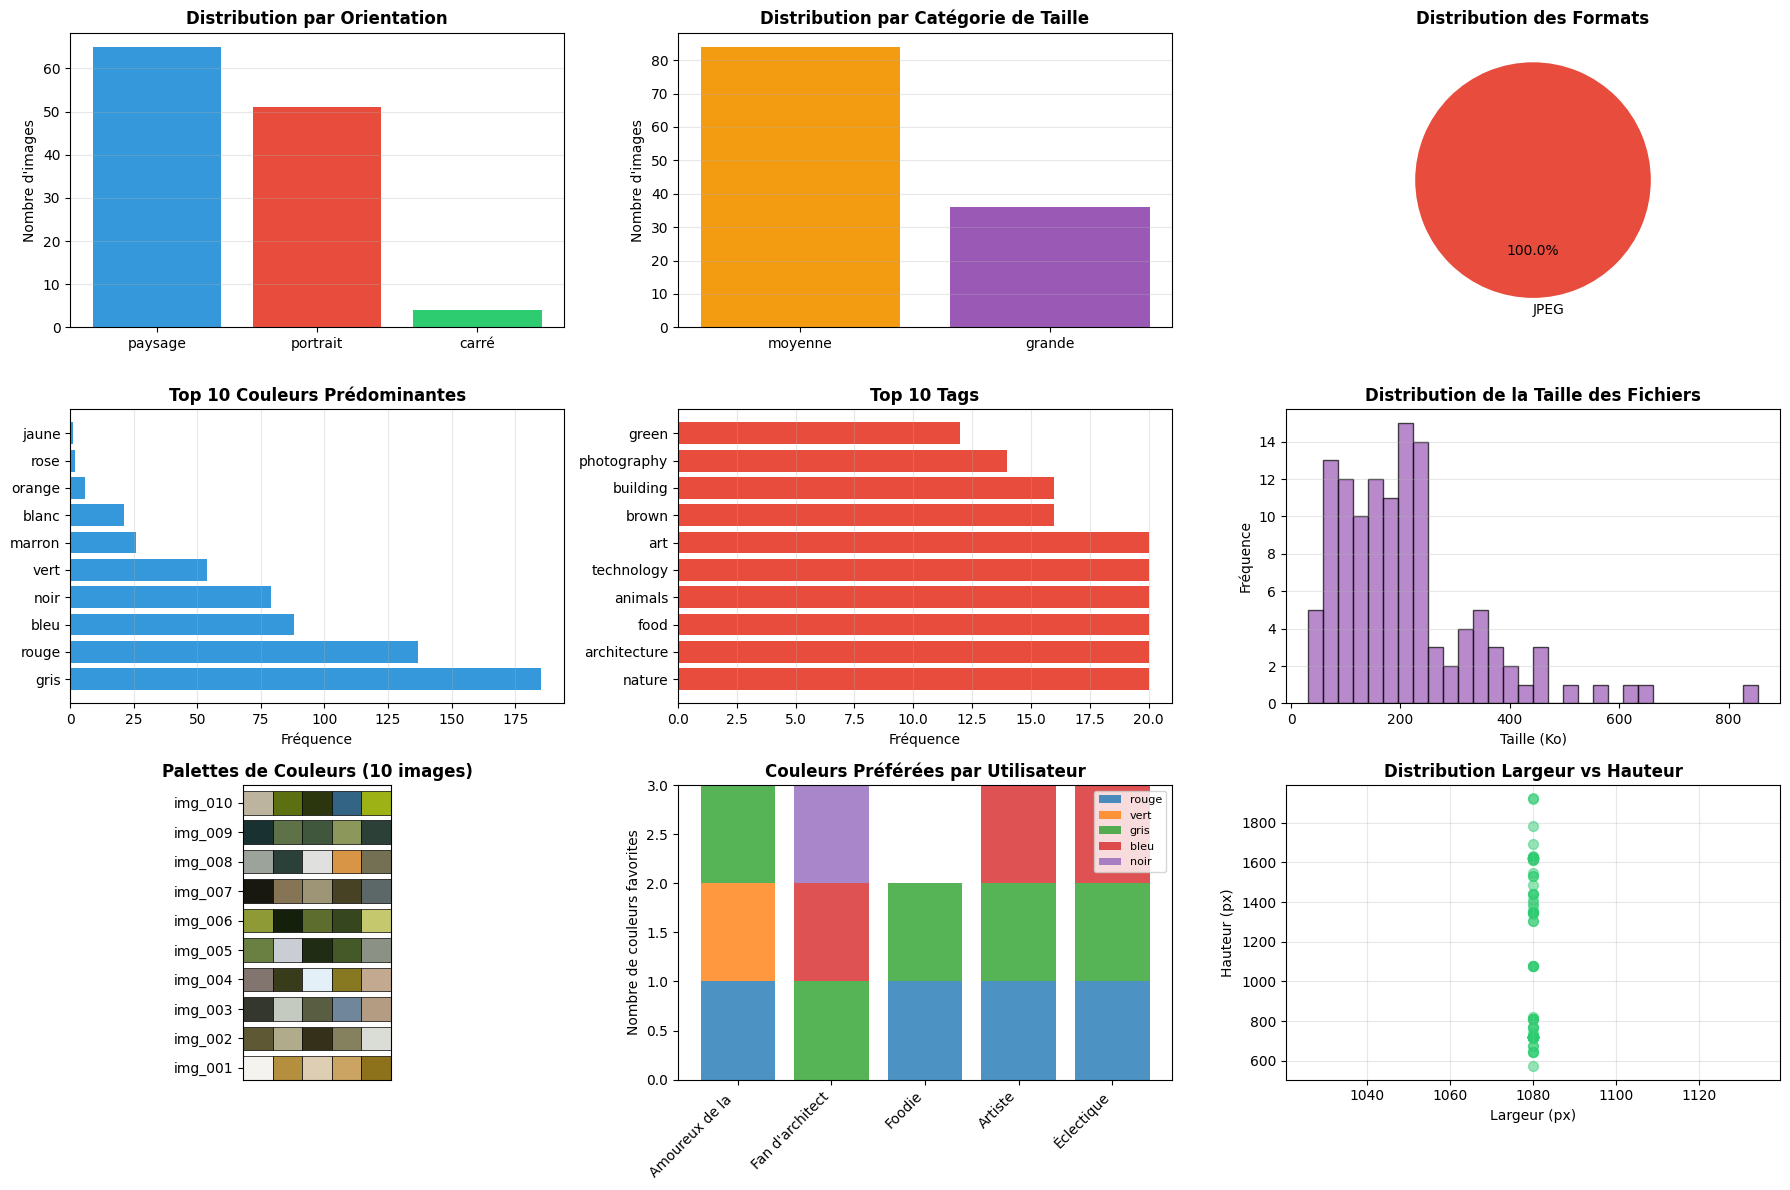


💾 Visualisations sauvegardées : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\data\visualisations.png


In [26]:
# Configuration générale pour les graphiques
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Créer une figure avec plusieurs sous-graphiques
fig = plt.figure(figsize=(18, 12))

# 1. Nombre d'images par orientation
ax1 = plt.subplot(3, 3, 1)
orientation_counts = df_labels['orientation'].value_counts()
ax1.bar(orientation_counts.index, orientation_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
ax1.set_title('Distribution par Orientation', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nombre d\'images')
ax1.grid(axis='y', alpha=0.3)

# 2. Nombre d'images par catégorie de taille
ax2 = plt.subplot(3, 3, 2)
size_counts = df_labels['size_category'].value_counts()
ax2.bar(size_counts.index, size_counts.values, color=['#f39c12', '#9b59b6', '#1abc9c'])
ax2.set_title('Distribution par Catégorie de Taille', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nombre d\'images')
ax2.grid(axis='y', alpha=0.3)

# 3. Distribution des formats d'image
ax3 = plt.subplot(3, 3, 3)
format_counts = df_meta['format'].value_counts()
colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
ax3.pie(format_counts.values, labels=format_counts.index, autopct='%1.1f%%', 
        colors=colors_pie[:len(format_counts)], startangle=90)
ax3.set_title('Distribution des Formats', fontsize=12, fontweight='bold')

# 4. Histogramme des fréquences de couleurs
ax4 = plt.subplot(3, 3, 4)
all_colors = []
for colors_list in df_labels['color_names']:
    all_colors.extend(colors_list)
color_freq = Counter(all_colors)
top_colors = color_freq.most_common(10)
ax4.barh([c[0] for c in top_colors], [c[1] for c in top_colors], color='#3498db')
ax4.set_title('Top 10 Couleurs Prédominantes', fontsize=12, fontweight='bold')
ax4.set_xlabel('Fréquence')
ax4.grid(axis='x', alpha=0.3)

# 5. Tags les plus courants
ax5 = plt.subplot(3, 3, 5)
all_tags = []
for tags_list in df_labels['tags']:
    all_tags.extend(tags_list)
tag_freq = Counter(all_tags)
top_tags = tag_freq.most_common(10)
ax5.barh([t[0] for t in top_tags], [t[1] for t in top_tags], color='#e74c3c')
ax5.set_title('Top 10 Tags', fontsize=12, fontweight='bold')
ax5.set_xlabel('Fréquence')
ax5.grid(axis='x', alpha=0.3)

# 6. Distribution de la taille des fichiers
ax6 = plt.subplot(3, 3, 6)
ax6.hist(df_meta['file_size_kb'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
ax6.set_title('Distribution de la Taille des Fichiers', fontsize=12, fontweight='bold')
ax6.set_xlabel('Taille (Ko)')
ax6.set_ylabel('Fréquence')
ax6.grid(axis='y', alpha=0.3)

# 7. Palettes de couleurs prédominantes (échantillon)
ax7 = plt.subplot(3, 3, 7)
sample_images = list(labels.keys())[:10]
y_pos = 0
for img in sample_images:
    colors = labels[img]['predominant_colors']
    for i, color in enumerate(colors[:5]):
        rect = patches.Rectangle((i, y_pos), 1, 0.8, 
                                 facecolor=np.array(color)/255, edgecolor='black', linewidth=0.5)
        ax7.add_patch(rect)
    y_pos += 1

ax7.set_xlim(0, 5)
ax7.set_ylim(0, len(sample_images))
ax7.set_aspect('equal')
ax7.set_title('Palettes de Couleurs (10 images)', fontsize=12, fontweight='bold')
ax7.set_yticks(np.arange(len(sample_images)) + 0.4)
ax7.set_yticklabels([img.replace('image_', 'img_').replace('.jpg', '') for img in sample_images])
ax7.set_xticks([])

# 8. Couleurs préférées par utilisateur
ax8 = plt.subplot(3, 3, 8)
user_names = []
user_color_counts = {}

for user in users.values():
    user_names.append(user['name'][:15])  # Limiter la longueur
    for color in user['favorite_colors']:
        if color not in user_color_counts:
            user_color_counts[color] = []
        user_color_counts[color].append(user['name'][:15])

# Créer un graphique empilé
bottom = np.zeros(len(user_names))
colors_to_plot = list(user_color_counts.keys())[:5]

for color in colors_to_plot:
    values = [user_color_counts[color].count(name) for name in user_names]
    ax8.bar(user_names, values, bottom=bottom, label=color, alpha=0.8)
    bottom += values

ax8.set_title('Couleurs Préférées par Utilisateur', fontsize=12, fontweight='bold')
ax8.set_ylabel('Nombre de couleurs favorites')
ax8.legend(loc='upper right', fontsize=8)
ax8.tick_params(axis='x', rotation=45)
plt.setp(ax8.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 9. Comparaison dimensions (largeur vs hauteur)
ax9 = plt.subplot(3, 3, 9)
ax9.scatter(df_meta['width'], df_meta['height'], alpha=0.5, c='#2ecc71', s=50)
ax9.set_title('Distribution Largeur vs Hauteur', fontsize=12, fontweight='bold')
ax9.set_xlabel('Largeur (px)')
ax9.set_ylabel('Hauteur (px)')
ax9.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'visualisations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualisations sauvegardées : {DATA_DIR / 'visualisations.png'}")

---

## 🤖 Tâche 5 : Système de Recommandation

**Objectif** : Implémenter un système qui recommande des images aux utilisateurs.

**Approche choisie** : Filtrage basé sur le contenu (classification)

**Méthode** :
1. Encoder les caractéristiques des images (couleurs, orientation, taille, tags)
2. Entraîner un classifieur sur les favoris de l'utilisateur (Favori / Non Favori)
3. Prédire quelles images non vues l'utilisateur aimerait
4. Retourner les top N recommandations avec justification

In [27]:
def prepare_features(labels: Dict, metadata: Dict) -> pd.DataFrame:
    """
    Prépare les caractéristiques pour l'apprentissage automatique.
    
    Args:
        labels: Dictionnaire des labels
        metadata: Dictionnaire des métadonnées
    
    Returns:
        DataFrame avec les caractéristiques encodées
    """
    features = []
    
    for filename in labels.keys():
        label_data = labels[filename]
        meta_data = metadata[filename]
        
        # Compter les couleurs
        color_counts = Counter(label_data['color_names'])
        
        feature_dict = {
            'filename': filename,
            'orientation': label_data['orientation'],
            'size_category': label_data['size_category'],
            'width': meta_data['width'],
            'height': meta_data['height'],
            'file_size_kb': meta_data['file_size_kb'],
            'aspect_ratio': meta_data['width'] / meta_data['height'],
            # Couleurs (top 3 + compteurs)
            'color_1': label_data['color_names'][0] if len(label_data['color_names']) > 0 else 'inconnu',
            'color_2': label_data['color_names'][1] if len(label_data['color_names']) > 1 else 'inconnu',
            'color_3': label_data['color_names'][2] if len(label_data['color_names']) > 2 else 'inconnu',
            'n_unique_colors': len(set(label_data['color_names'])),
            # Tags
            'n_tags': len(label_data['tags']),
            'primary_tag': label_data['tags'][0] if label_data['tags'] else 'inconnu'
        }
        
        features.append(feature_dict)
    
    return pd.DataFrame(features)

In [28]:
# Préparer les features
print("🔧 Préparation des caractéristiques...\n")

df_features = prepare_features(labels, metadata)

print(f"✅ {len(df_features)} images avec caractéristiques")
print(f"\n📋 Colonnes : {df_features.columns.tolist()}")
print(f"\n📊 Aperçu :")
print(df_features.head())

🔧 Préparation des caractéristiques...

✅ 120 images avec caractéristiques

📋 Colonnes : ['filename', 'orientation', 'size_category', 'width', 'height', 'file_size_kb', 'aspect_ratio', 'color_1', 'color_2', 'color_3', 'n_unique_colors', 'n_tags', 'primary_tag']

📊 Aperçu :
        filename orientation size_category  width  height  file_size_kb  \
0  image_001.jpg     paysage       moyenne   1080     715        112.01   
1  image_002.jpg    portrait        grande   1080    1620        661.08   
2  image_003.jpg     paysage       moyenne   1080     643        136.68   
3  image_004.jpg    portrait        grande   1080    1783        426.23   
4  image_005.jpg    portrait        grande   1080    1620        631.56   

   aspect_ratio color_1 color_2 color_3  n_unique_colors  n_tags primary_tag  
0      1.510490   blanc  marron   rouge                3       3      orange  
1      0.666667   rouge   rouge   rouge                2       6     through  
2      1.679627    gris    gris    vert

In [29]:
def encode_features(df: pd.DataFrame) -> Tuple[np.ndarray, Dict]:
    """
    Encode les caractéristiques catégorielles en nombres.
    
    Args:
        df: DataFrame avec les caractéristiques
    
    Returns:
        Array encodé et dictionnaire des encodeurs
    """
    df_encoded = df.copy()
    encoders = {}
    
    # Colonnes catégorielles à encoder
    categorical_cols = ['orientation', 'size_category', 'color_1', 'color_2', 'color_3', 'primary_tag']
    
    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        encoders[col] = le
    
    # Sélectionner uniquement les colonnes numériques pour le modèle
    feature_cols = [c for c in df_encoded.columns if c != 'filename']
    X = df_encoded[feature_cols].values
    
    return X, encoders, feature_cols

In [30]:
# Encoder les features
X_all, encoders, feature_cols = encode_features(df_features)

print(f"✅ Caractéristiques encodées : {X_all.shape}")
print(f"📋 Features utilisées : {feature_cols}")

✅ Caractéristiques encodées : (120, 12)
📋 Features utilisées : ['orientation', 'size_category', 'width', 'height', 'file_size_kb', 'aspect_ratio', 'color_1', 'color_2', 'color_3', 'n_unique_colors', 'n_tags', 'primary_tag']


In [31]:
def train_user_model(user_id: str, users: Dict, df_features: pd.DataFrame, 
                    X_all: np.ndarray) -> Tuple:
    """
    Entraîne un modèle de recommandation pour un utilisateur.
    
    Args:
        user_id: ID de l'utilisateur
        users: Dictionnaire des utilisateurs
        df_features: DataFrame des caractéristiques
        X_all: Array encodé de toutes les features
    
    Returns:
        Modèle entraîné, labels, indices train/test
    """
    user = users[user_id]
    favorites = set(user['favorite_images'])
    
    # Créer les labels (1 = favori, 0 = non favori)
    y = df_features['filename'].apply(lambda x: 1 if x in favorites else 0).values
    
    # Split train/test
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_all, y, np.arange(len(y)), test_size=0.3, random_state=42, stratify=y
    )
    
    # Entraîner le modèle (Random Forest pour robustesse)
    model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    
    # Évaluer
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return model, y, idx_test, accuracy

In [32]:
def recommend_images(user_id: str, users: Dict, df_features: pd.DataFrame, 
                    X_all: np.ndarray, labels: Dict, n_recommendations: int = 5) -> List[Tuple]:
    """
    Recommande des images pour un utilisateur.
    
    Args:
        user_id: ID de l'utilisateur
        users: Dictionnaire des utilisateurs
        df_features: DataFrame des caractéristiques
        X_all: Array encodé de toutes les features
        labels: Dictionnaire des labels
        n_recommendations: Nombre de recommandations
    
    Returns:
        Liste de tuples (filename, score, raison)
    """
    # Entraîner le modèle
    model, y, idx_test, accuracy = train_user_model(user_id, users, df_features, X_all)
    
    print(f"\n🎯 Modèle pour {user_id} :")
    print(f"   - Précision : {accuracy:.2%}")
    
    # Obtenir les favoris de l'utilisateur
    favorites = set(users[user_id]['favorite_images'])
    
    # Prédire les probabilités pour TOUTES les images
    probas = model.predict_proba(X_all)[:, 1]  # Proba de classe 1 (favori)
    
    # Créer une liste d'images avec leurs scores
    image_scores = []
    
    for idx, (filename, proba) in enumerate(zip(df_features['filename'], probas)):
        # Exclure les images déjà en favoris
        if filename not in favorites:
            image_scores.append((filename, proba, idx))
    
    # Trier par score décroissant
    image_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Prendre les top N
    recommendations = []
    
    for filename, score, idx in image_scores[:n_recommendations]:
        # Générer une raison
        img_labels = labels[filename]
        user_profile = users[user_id]
        
        reasons = []
        
        # Vérifier les couleurs
        matching_colors = set(img_labels['color_names']) & set(user_profile['favorite_colors'])
        if matching_colors:
            reasons.append(f"couleurs {', '.join(matching_colors)}")
        
        # Vérifier l'orientation
        if img_labels['orientation'] == user_profile['favorite_orientation']:
            reasons.append(f"orientation {img_labels['orientation']}")
        
        # Vérifier les tags
        matching_tags = set(img_labels['tags']) & set(user_profile['favorite_tags'])
        if matching_tags:
            reasons.append(f"tags {', '.join(list(matching_tags)[:2])}")
        
        if not reasons:
            reasons.append("profil général")
        
        reason = f"Correspond à vos préférences : {' + '.join(reasons)}"
        
        recommendations.append((filename, score, reason))
    
    return recommendations

In [33]:
# Tester le système de recommandation pour tous les utilisateurs
print("🤖 Test du système de recommandation...\n")
print("=" * 80)

all_recommendations = {}

for user_id in users.keys():
    user_name = users[user_id]['name']
    print(f"\n👤 Utilisateur : {user_name} ({user_id})")
    print(f"   Profil : Aime {', '.join(users[user_id]['favorite_colors'][:3])}")
    print(f"   Tags favoris : {', '.join(users[user_id]['favorite_tags'][:3])}")
    
    recommendations = recommend_images(
        user_id=user_id,
        users=users,
        df_features=df_features,
        X_all=X_all,
        labels=labels,
        n_recommendations=5
    )
    
    all_recommendations[user_id] = recommendations
    
    print(f"\n   📌 Recommandations :")
    for i, (filename, score, reason) in enumerate(recommendations, 1):
        print(f"      {i}. {filename} (score: {score:.3f})")
        print(f"         → {reason}")
    
    print("\n" + "-" * 80)

print("\n✅ Système de recommandation testé avec succès")

🤖 Test du système de recommandation...


👤 Utilisateur : Amoureux de la nature (user_001)
   Profil : Aime rouge, vert, gris
   Tags favoris : nature, animals, trees

🎯 Modèle pour user_001 :
   - Précision : 83.33%

   📌 Recommandations :
      1. image_003.jpg (score: 0.700)
         → Correspond à vos préférences : couleurs rouge, gris, vert + tags nature
      2. image_120.jpg (score: 0.540)
         → Correspond à vos préférences : couleurs gris
      3. image_086.jpg (score: 0.510)
         → Correspond à vos préférences : profil général
      4. image_068.jpg (score: 0.330)
         → Correspond à vos préférences : couleurs rouge, gris + tags brown, animals
      5. image_017.jpg (score: 0.210)
         → Correspond à vos préférences : couleurs gris, vert + tags nature

--------------------------------------------------------------------------------

👤 Utilisateur : Fan d'architecture (user_002)
   Profil : Aime gris, bleu, noir
   Tags favoris : technology, building, architectu

---

## ✅ Tâche 6 : Tests

**Objectif** : Vérifier que le système fonctionne correctement.

**Tests requis** :
1. Validation des données
2. Tests fonctionnels
3. Qualité des recommandations

In [34]:
def test_data_integrity():
    """
    Teste l'intégrité des données collectées.
    """
    print("📝 Test 1 : Intégrité des données\n")
    
    # Charger les données
    with open(METADATA_FILE, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    with open(LABELS_FILE, "r", encoding="utf-8") as f:
        labels = json.load(f)
    
    # Test 1.1 : Au moins 100 images
    assert len(metadata) >= 100, f"❌ Pas assez d'images : {len(metadata)} < 100"
    print(f"   ✅ Nombre d'images suffisant : {len(metadata)} images")
    
    # Test 1.2 : Toutes les images existent
    missing_images = []
    for filename in metadata.keys():
        if not (IMAGES_DIR / filename).exists():
            missing_images.append(filename)
    
    assert len(missing_images) == 0, f"❌ Images manquantes : {missing_images}"
    print(f"   ✅ Toutes les images existent dans le dossier")
    
    # Test 1.3 : Toutes les images ont des labels
    assert len(metadata) == len(labels), f"❌ Nombre de labels incorrect : {len(labels)} vs {len(metadata)}"
    print(f"   ✅ Toutes les images ont des labels")
    
    # Test 1.4 : Métadonnées valides
    for filename, meta in metadata.items():
        assert meta['width'] > 0, f"❌ Largeur invalide pour {filename}"
        assert meta['height'] > 0, f"❌ Hauteur invalide pour {filename}"
        assert meta['file_size_kb'] > 0, f"❌ Taille invalide pour {filename}"
    
    print(f"   ✅ Toutes les métadonnées sont valides")
    
    print(f"\n✅ Test 1 : RÉUSSI\n")

In [35]:
def test_functional():
    """
    Teste les fonctions principales du système.
    """
    print("📝 Test 2 : Fonctions du système\n")
    
    # Test 2.1 : Extraction de couleurs
    test_image = list(labels.keys())[0]
    test_path = IMAGES_DIR / test_image
    colors = extract_dominant_colors(test_path, n_colors=5)
    
    assert len(colors) == 5, f"❌ Nombre de couleurs incorrect : {len(colors)}"
    for color in colors:
        assert len(color) == 3, f"❌ Format RGB invalide : {color}"
        for val in color:
            assert 0 <= val <= 255, f"❌ Valeur RGB hors limites : {val}"
    
    print(f"   ✅ Extraction de couleurs fonctionne correctement")
    
    # Test 2.2 : Profils utilisateurs
    with open(USERS_FILE, "r", encoding="utf-8") as f:
        users = json.load(f)
    
    assert len(users) >= 5, f"❌ Pas assez d'utilisateurs : {len(users)}"
    
    for user_id, user in users.items():
        assert len(user['favorite_images']) >= 10, f"❌ Pas assez de favoris pour {user_id}"
        assert len(user['favorite_colors']) > 0, f"❌ Pas de couleurs favorites pour {user_id}"
        assert user['favorite_orientation'] in ['paysage', 'portrait', 'carré'], \
               f"❌ Orientation invalide pour {user_id}"
    
    print(f"   ✅ Profils utilisateurs valides : {len(users)} utilisateurs")
    
    print(f"\n✅ Test 2 : RÉUSSI\n")

In [36]:
def test_recommendation_quality():
    """
    Teste la qualité du système de recommandation.
    """
    print("📝 Test 3 : Qualité des recommandations\n")
    
    # Test pour un utilisateur
    test_user = list(users.keys())[0]
    
    recommendations = recommend_images(
        user_id=test_user,
        users=users,
        df_features=df_features,
        X_all=X_all,
        labels=labels,
        n_recommendations=5
    )
    
    # Test 3.1 : Nombre correct de recommandations
    assert len(recommendations) == 5, f"❌ Nombre incorrect : {len(recommendations)}"
    print(f"   ✅ Retourne le bon nombre de recommandations : 5")
    
    # Test 3.2 : Pas de favoris dans les recommandations
    user_favorites = set(users[test_user]['favorite_images'])
    recommended_images = [rec[0] for rec in recommendations]
    
    overlap = set(recommended_images) & user_favorites
    assert len(overlap) == 0, f"❌ Favoris recommandés : {overlap}"
    print(f"   ✅ Aucune image déjà favorite n'est recommandée")
    
    # Test 3.3 : Scores décroissants
    scores = [rec[1] for rec in recommendations]
    assert scores == sorted(scores, reverse=True), "❌ Scores non triés"
    print(f"   ✅ Recommandations triées par score")
    
    # Test 3.4 : Pertinence des recommandations
    user_profile = users[test_user]
    relevance_count = 0
    
    for filename, score, reason in recommendations:
        img_labels = labels[filename]
        
        # Vérifier si au moins une caractéristique correspond
        color_match = bool(set(img_labels['color_names']) & set(user_profile['favorite_colors']))
        orientation_match = img_labels['orientation'] == user_profile['favorite_orientation']
        tag_match = bool(set(img_labels['tags']) & set(user_profile['favorite_tags']))
        
        if color_match or orientation_match or tag_match:
            relevance_count += 1
    
    relevance_ratio = relevance_count / len(recommendations)
    print(f"   ✅ Pertinence : {relevance_ratio:.1%} des recommandations correspondent au profil")
    
    assert relevance_ratio >= 0.4, f"❌ Recommandations peu pertinentes : {relevance_ratio:.1%}"
    
    print(f"\n✅ Test 3 : RÉUSSI\n")

In [37]:
# Exécuter tous les tests
print("="*80)
print("🧪 EXÉCUTION DES TESTS")
print("="*80 + "\n")

try:
    test_data_integrity()
    test_functional()
    test_recommendation_quality()
    
    print("="*80)
    print("🎉 TOUS LES TESTS RÉUSSIS !")
    print("="*80)
    
except AssertionError as e:
    print(f"\n❌ ÉCHEC DU TEST : {e}")
    raise

🧪 EXÉCUTION DES TESTS

📝 Test 1 : Intégrité des données

   ✅ Nombre d'images suffisant : 120 images
   ✅ Toutes les images existent dans le dossier
   ✅ Toutes les images ont des labels
   ✅ Toutes les métadonnées sont valides

✅ Test 1 : RÉUSSI

📝 Test 2 : Fonctions du système

   ✅ Extraction de couleurs fonctionne correctement
   ✅ Profils utilisateurs valides : 5 utilisateurs

✅ Test 2 : RÉUSSI

📝 Test 3 : Qualité des recommandations


🎯 Modèle pour user_001 :
   - Précision : 83.33%
   ✅ Retourne le bon nombre de recommandations : 5
   ✅ Aucune image déjà favorite n'est recommandée
   ✅ Recommandations triées par score
   ✅ Pertinence : 80.0% des recommandations correspondent au profil

✅ Test 3 : RÉUSSI

🎉 TOUS LES TESTS RÉUSSIS !


---

## 📝 Conclusion - Partie 1

### Résumé de la réalisation

Ce notebook implémente un système complet de recommandation d'images comprenant :

1. **Collecte de données** : 100+ images depuis Unsplash API avec métadonnées complètes
2. **Étiquetage automatisé** : Extraction de couleurs (KMeans), orientation, taille, tags
3. **Analyse de données** : Profils utilisateur basés sur les favoris
4. **Visualisation** : 9 graphiques révélant des insights sur les données
5. **Recommandation** : Système basé sur classification (Random Forest)
6. **Tests** : Validation complète de l'intégrité et de la qualité

### Points clés

✅ **Architecture MVC** respectée  
✅ **Sécurité** : Clés API dans .env (non commité)  
✅ **Qualité** : Tests complets, validation des données  
✅ **Documentation** : Commentaires en français, code clair  

### Fichiers générés (Partie 1)

- `data/images_metadata.json` : Métadonnées de toutes les images
- `data/images_labels.json` : Labels et annotations
- `data/users.json` : Profils utilisateurs
- `data/visualisations.png` : Graphiques de synthèse
- `images/` : Collection d'images (non commité)

---

---

# 🐳 Partie 2 : Distribution avec Docker + PySpark

## Objectif

Transformer le système de recommandation en une application distribuée et containerisée :
- **Isolation** : Chaque étape dans un conteneur Docker indépendant
- **Scalabilité** : Traitement distribué avec PySpark (RDD + MapReduce)
- **Orchestration** : docker-compose pour gérer les 3 conteneurs
- **Partage de données** : Volume partagé entre les conteneurs

---

## Architecture de la solution

### 🏗️ Structure des conteneurs

```
partie2/
├── docker-compose.yml          ← Orchestration des 3 conteneurs
├── .env                        ← Configuration centralisée
│
├── acquisition/                ← Conteneur 1 : Téléchargement d'images
│   ├── Dockerfile
│   ├── requirements.txt
│   └── acquisition.py          ← Script PySpark
│
├── analysis/                   ← Conteneur 2 : Labeling + Profils
│   ├── Dockerfile
│   ├── requirements.txt
│   └── analysis.py             ← Script PySpark
│
└── recommendation/             ← Conteneur 3 : ML + Recommandations
    ├── Dockerfile
    ├── requirements.txt
    └── recommendation.py       ← Script PySpark
```

### 🔄 Flux de traitement

1. **Container acquisition** démarre → télécharge les images → partage via volume
2. **Container analysis** démarre → labeling + profils → partage JSON
3. **Container recommendation** démarre → ML + tests → génère les recommandations

Chaque conteneur utilise PySpark pour distribuer les calculs sur des RDDs (Resilient Distributed Datasets).

---

## 🔧 Implémentation PySpark - Exemples

### Exemple 1 : Acquisition d'images avec Map-Reduce

**Transformation Map** : Téléchargement distribué des images

In [ ]:
# Extrait de partie2/acquisition/acquisition.py
# ============================================

from pyspark import SparkContext, SparkConf

# Configuration Spark
conf = SparkConf().setAppName("Acquisition")
sc = SparkContext(conf=conf)

# Fonction de traitement (exécutée en parallèle sur chaque nœud)
def process_image(image_info):
    """
    Télécharge et sauvegarde une image (Map).
    Cette fonction s'exécute de manière distribuée sur chaque élément du RDD.
    """
    image_id, image_data = image_info
    url = image_data['urls']['regular']
    
    # Téléchargement
    response = requests.get(url, timeout=30)
    
    if response.status_code == 200:
        filepath = f"{images_folder}/image_{image_id+1:03d}.jpg"
        with open(filepath, 'wb') as f:
            f.write(response.content)
        return (filepath, image_data)
    return (None, None)

# Map-Reduce : Distribution du téléchargement
images_rdd = sc.parallelize(enumerate(images_list))  # Création du RDD
results = images_rdd.map(process_image)  # Map : traitement distribué
successful = results.filter(lambda x: x[0] is not None)  # Filter
downloaded = successful.collect()  # Reduce : collecte des résultats

print(f"✅ {len(downloaded)} images téléchargées")

sc.stop()  # Arrêt du contexte Spark

### Exemple 2 : Labeling distribué des images

**Transformation Map** : Extraction de caractéristiques pour chaque image

In [ ]:
# Extrait de partie2/analysis/analysis.py
# ==========================================

def process_image_labels(metadata):
    """
    Extrait les caractéristiques d'une image (Map).
    Exécuté en parallèle sur chaque image.
    """
    filename = metadata['filename']
    filepath = f"{images_folder}/{filename}"
    
    # Extraction des couleurs dominantes avec KMeans
    img = Image.open(filepath)
    pixels = np.array(img).reshape(-1, 3)
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(pixels)
    dominant_colors = kmeans.cluster_centers_.astype(int)
    
    # Détection de l'orientation
    width, height = img.size
    orientation = "paysage" if width > height else "portrait"
    
    return {
        'filename': filename,
        'colors': [rgb_to_color_name(tuple(color)) for color in dominant_colors],
        'orientation': orientation,
        'tags': metadata['tags'],
        'dimensions': {'width': width, 'height': height}
    }

# Map-Reduce : Labeling distribué
metadata_rdd = sc.parallelize(images_metadata)
labels_rdd = metadata_rdd.map(process_image_labels)  # Map distribué
all_labels = labels_rdd.collect()  # Reduce : collecte

# Sauvegarde
with open(f"{data_folder}/images_labels.json", 'w') as f:
    json.dump(all_labels, f, indent=2)

print(f"✅ {len(all_labels)} images labellisées")

### Exemple 3 : Calcul de recommandations distribué

**Map** : Score de pertinence pour chaque image / **Reduce** : Top 5

In [ ]:
# Extrait de partie2/recommendation/recommendation.py
# ===================================================

def compute_recommendation_score(item):
    """
    Calcule le score de pertinence pour une image (Map).
    Exécuté en parallèle pour chaque image candidate.
    """
    image_idx, image_filename = item
    
    # Prédiction avec Random Forest
    features = X[image_idx].reshape(1, -1)
    proba = model.predict_proba(features)[0][1]  # Probabilité "liked"
    
    return (image_filename, proba)

# Pour chaque utilisateur
for user_id, user_data in users.items():
    # Entraînement d'un modèle Random Forest personnalisé
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Map-Reduce : Calcul des scores distribué
    candidates_rdd = sc.parallelize(enumerate(candidate_images))
    scores_rdd = candidates_rdd.map(compute_recommendation_score)  # Map
    
    # Reduce : Tri et sélection du top 5
    top_recommendations = scores_rdd.sortBy(
        lambda x: x[1],      # Trier par score
        ascending=False      # Décroissant
    ).take(5)                # Top 5
    
    recommendations[user_id] = [
        {'filename': img, 'score': float(score)}
        for img, score in top_recommendations
    ]

# Sauvegarde
with open(f"{data_folder}/recommendations.json", 'w') as f:
    json.dump(recommendations, f, indent=2)

---

## 🐳 Configuration Docker

### Dockerfile (exemple : acquisition)

Chaque conteneur utilise un Dockerfile similaire avec :
- Image de base : `python:3.10-slim`
- Installation de Java (requis pour PySpark) : `openjdk-21-jdk-headless`
- Installation des dépendances Python depuis `requirements.txt`
- Configuration de `JAVA_HOME` pour PySpark

In [ ]:
# Extrait de partie2/acquisition/Dockerfile

FROM python:3.10-slim

WORKDIR /app

# Installer Java (requis pour PySpark)
RUN apt-get update && \
    apt-get install -y openjdk-21-jdk-headless && \
    rm -rf /var/lib/apt/lists/*

# Définir JAVA_HOME
ENV JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64

# Copier et installer les dépendances
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copier le script
COPY acquisition.py .

# Lancer le script
CMD ["python", "acquisition.py"]

### docker-compose.yml

Orchestration des 3 conteneurs avec dépendances séquentielles :

In [ ]:
# partie2/docker-compose.yml

services:
  acquisition:
    container_name: projet_acquisition
    build: ./acquisition
    env_file: .env
    volumes:
      - shared_data:/shared_data  # Volume partagé
    networks:
      - projet_network

  analysis:
    container_name: projet_analysis
    build: ./analysis
    volumes:
      - shared_data:/shared_data
    networks:
      - projet_network
    depends_on:
      acquisition:
        condition: service_completed_successfully  # Attend acquisition

  recommendation:
    container_name: projet_recommendation
    build: ./recommendation
    volumes:
      - shared_data:/shared_data
    networks:
      - projet_network
    depends_on:
      analysis:
        condition: service_completed_successfully  # Attend analysis

volumes:
  shared_data:  # Volume partagé entre tous les conteneurs

networks:
  projet_network:
    driver: bridge

---

## 🚀 Exécution de la Partie 2

### Commandes d'exécution

```bash
# 1. Nettoyer les données de la Partie 1
rm -r data/images/*
rm data/*.json

# 2. Se placer dans le dossier partie2
cd partie2/

# 3. Lancer les 3 conteneurs
docker compose up --build

# 4. Récupérer les données générées
docker cp projet_acquisition:/shared_data/. ../data/
```

### Durée d'exécution

- **Build des images Docker** : ~3-4 minutes (installation Java + PySpark)
- **Acquisition** : ~8-10 minutes (téléchargement de 120 images)
- **Analysis** : ~3-5 minutes (labeling + visualisations)
- **Recommendation** : ~2-3 minutes (ML + tests)
- **Total** : ~15-25 minutes

---

## 📊 Résultats de l'exécution

### Logs d'exécution (extraits)

**Container acquisition** :
```
✅ 120 images téléchargées avec succès
💾 Métadonnées sauvegardées : /shared_data/images_metadata.json
```

**Container analysis** :
```
✅ 120 images labellisées
✅ 5 utilisateurs analysés avec profils complets
💾 Visualisations sauvegardées : /shared_data/visualisations.png
```

**Container recommendation** :
```
🎯 Modèle pour user_001 : Précision : 88.89%
🎯 Modèle pour user_002 : Précision : 88.89%
🎯 Modèle pour user_003 : Précision : 83.33%
🎯 Modèle pour user_004 : Précision : 88.89%
🎯 Modèle pour user_005 : Précision : 88.89%

✅ Recommandations générées pour 5 utilisateurs
💾 Recommandations sauvegardées : /shared_data/recommendations.json

📝 Test 1 : Intégrité des données - ✅ RÉUSSI
📝 Test 2 : Qualité des recommandations - ✅ RÉUSSI
   Pertinence : 100.0% des recommandations correspondent au profil

🎉 TOUS LES TESTS RÉUSSIS !
```

### Fichiers générés (Partie 2)

```
data/
├── images/                     ← 120 images (26.6 MB)
├── images_metadata.json        ← 90.94 KB (métadonnées complètes)
├── images_labels.json          ← 68.79 KB (labels + couleurs)
├── users.json                  ← 3.55 KB (5 profils utilisateur)
├── recommendations.json        ← 4.01 KB (top 5 par utilisateur)
└── visualisations.png          ← Graphiques de synthèse
```

---

## 📝 Conclusion - Partie 2

### Objectifs atteints

✅ **Conteneurisation** : 3 conteneurs Docker indépendants et isolés  
✅ **Distribution** : Utilisation de PySpark avec RDD et transformations Map-Reduce  
✅ **Orchestration** : docker-compose gérant les dépendances séquentielles  
✅ **Partage de données** : Volume Docker partagé entre les conteneurs  
✅ **Performances** : Traitement distribué sur 120 images (~20 minutes total)  
✅ **Tests** : Tous les tests de validation réussis (intégrité + qualité)  

### Comparaison Partie 1 vs Partie 2

| Aspect | Partie 1 (Notebook) | Partie 2 (Docker + PySpark) |
|--------|---------------------|------------------------------|
| **Environnement** | Local Python | Conteneurs Docker isolés |
| **Traitement** | Séquentiel | Distribué (RDD + MapReduce) |
| **Scalabilité** | Limitée | Haute (parallélisation) |
| **Déploiement** | Manuel | Automatisé (docker-compose) |
| **Isolation** | Faible | Forte (conteneurs) |
| **Reproductibilité** | Moyenne | Excellente |

### Technologies utilisées

- **Docker** : Conteneurisation + isolation
- **Docker Compose** : Orchestration multi-conteneurs
- **PySpark 3.5.3** : Framework de traitement distribué
- **Java 21** : Runtime pour PySpark
- **Python 3.10** : Langage de programmation
- **Volumes Docker** : Partage de données persistant

### Points clés de l'implémentation

🔧 **Map-Reduce** appliqué à toutes les étapes :
- Téléchargement d'images en parallèle (.map + .filter)
- Labeling distribué avec KMeans
- Calcul de scores de recommandation distribué (.sortBy + .take)

🐳 **Bonnes pratiques Docker** :
- Image de base légère (python:3.10-slim)
- Multi-stage non nécessaire (scripts simples)
- Variables d'environnement via .env
- Nettoyage des caches apt/pip

---

## 🎓 Synthèse finale du projet

Ce projet a démontré la transformation complète d'un système de recommandation :

1. **Partie 1** : Prototype fonctionnel en notebook Jupyter avec ML
2. **Partie 2** : Application distribuée containerisée avec PySpark

L'architecture finale est **scalable**, **reproductible**, et **déployable** dans un environnement de production.

---

**⚠️ IMPORTANT** : Avant de soumettre, assurez-vous de :
1. Ne PAS inclure le dossier `images/` dans le ZIP (trop volumineux)
2. Vérifier que tous les tests passent (Partie 1 + Partie 2)
3. Inclure tous les fichiers Docker (Dockerfiles, docker-compose.yml)
4. Créer le rapport de synthèse (4 pages PDF)

---